In [ ]:
!pip install 'qiskit[all]'
!pip install cplex

In [ ]:
!pip install matplotlib==3.1.3

In [ ]:
!git clone https://github.com/loukasa/graph-coarsening.git && cd graph-coarsening && pip install .
!pip install pygsp

In [19]:
# Load the packages that are required
import numpy as np
import operator
import matplotlib.pyplot as plt

import sys
if sys.version_info < (3, 6):
    raise Exception('Please use Python version 3.6 or greater.')

try:
    import cplex
    from cplex.exceptions import CplexError
except:
    print("Warning: Cplex not found.")
import math

# Qiskit packages
from qiskit import BasicAer
from qiskit.quantum_info import Pauli
from qiskit.aqua import QuantumInstance, aqua_globals
from qiskit.aqua.algorithms import NumPyMinimumEigensolver, VQE,QAOA
from qiskit.circuit.library import TwoLocal
from qiskit.aqua.components.optimizers import SPSA
from qiskit.aqua.operators import WeightedPauliOperator
from qiskit.algorithms.optimizers import COBYLA, SLSQP, ADAM
from qiskit.optimization.applications.ising import vehicle_routing
# setup aqua logging
import logging
from qiskit.aqua._logging import set_logging_config, build_logging_config
#set_logging_config(build_logging_config(logging.DEBUG))  # choose INFO, DEBUG to see the log

In [5]:
# Initialize the problem by defining the parameters
n = 14  # number of nodes + depot (n+1)
K = 5   # number of vehicles

In [6]:
#Create a random Graphs
class Initializer():

    def __init__(self, n):
        self.n = n

    def generate_instance(self):

        n = self.n

        np.random.seed(1043)

        xc = (np.random.rand(n) - 0.5) * 10
        yc = (np.random.rand(n) - 0.5) * 10

        instance = np.zeros([n, n])
        for ii in range(0, n):
            for jj in range(ii + 1, n):
                instance[ii, jj] = (xc[ii] - xc[jj]) ** 2 + (yc[ii] - yc[jj]) ** 2
                instance[jj, ii] = instance[ii, jj]

        return xc, yc, instance

(-5.0, 5.0)

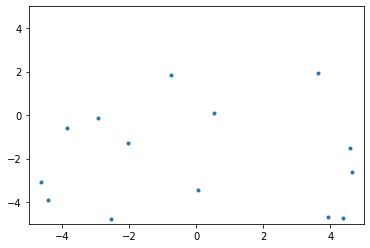

In [7]:
# Initialize the problem by randomly generating the instance
initializer = Initializer(n)
xc,yc,instance = initializer.generate_instance()

plt.plot(xc,yc,'.')

plt.xlim(-5,5)
plt.ylim(-5,5)

In [8]:
class ClassicalOptimizer:

    def __init__(self, instance,n,K):

        self.instance = instance
        self.n = n  # number of nodes
        self.K = K  # number of vehicles


    def compute_allowed_combinations(self):
        f = math.factorial
        return f(self.n) / f(self.K) / f(self.n-self.K)


    def cplex_solution(self):

        # refactoring
        instance = self.instance
        n = self.n
        K = self.K

        my_obj = list(instance.reshape(1, n**2)[0])+[0. for x in range(0,n-1)]
        my_ub = [1 for x in range(0,n**2+n-1)]
        my_lb = [0 for x in range(0,n**2)] + [0.1 for x in range(0,n-1)]
        my_ctype = "".join(['I' for x in range(0,n**2)]) + "".join(['C' for x in range(0,n-1)])

        my_rhs = 2*([K] + [1 for x in range(0,n-1)]) + [1-0.1 for x in range(0,(n-1)**2-(n-1))] + [0 for x in range(0,n)]
        my_sense = "".join(['E' for x in range(0,2*n)]) + "".join(['L' for x in range(0,(n-1)**2-(n-1))])+"".join(['E' for x in range(0,n)])

        try:
            my_prob = cplex.Cplex()
            self.populatebyrow(my_prob,my_obj,my_ub,my_lb,my_ctype,my_sense,my_rhs)

            my_prob.solve()

        except CplexError as exc:
            print(exc)
            return

        x = my_prob.solution.get_values()
        x = np.array(x)
        cost = my_prob.solution.get_objective_value()

        return x,cost


    def populatebyrow(self,prob,my_obj,my_ub,my_lb,my_ctype,my_sense,my_rhs):

        n = self.n

        prob.objective.set_sense(prob.objective.sense.minimize)
        prob.variables.add(obj = my_obj, lb = my_lb, ub = my_ub, types = my_ctype)

        prob.set_log_stream(None)
        prob.set_error_stream(None)
        prob.set_warning_stream(None)
        prob.set_results_stream(None)

        rows = []
        for ii in range(0,n):
            col = [x for x in range(0+n*ii,n+n*ii)]
            coef = [1 for x in range(0,n)]
            rows.append([col, coef])

        for ii in range(0,n):
            col = [x for x in range(0+ii,n**2,n)]
            coef = [1 for x in range(0,n)]

            rows.append([col, coef])

        # Sub-tour elimination constraints:
        for ii in range(0, n):
            for jj in range(0,n):
                if (ii != jj)and(ii*jj>0):

                    col = [ii+(jj*n), n**2+ii-1, n**2+jj-1]
                    coef = [1, 1, -1]

                    rows.append([col, coef])

        for ii in range(0,n):
            col = [(ii)*(n+1)]
            coef = [1]
            rows.append([col, coef])

        prob.linear_constraints.add(lin_expr=rows, senses=my_sense, rhs=my_rhs)

In [ ]:
instance

In [9]:
# Instantiate the classical optimizer class
classical_optimizer = ClassicalOptimizer(instance,n,K)

# Print number of feasible solutions
print('Number of feasible solutions = ' + str(classical_optimizer.compute_allowed_combinations()))

Number of feasible solutions = 2002.0


In [10]:
# Solve the problem in a classical fashion via CPLEX
x = None
z = None
try:
    x,classical_cost = classical_optimizer.cplex_solution()
    # Put the solution in the z variable
    z = [x[ii] for ii in range(n**2) if ii//n != ii%n]
    # Print the solution
    print(z)
except:
    print("CPLEX may be missing.")

[0.0, -0.0, -0.0, -0.0, 1.0, 1.0, 1.0, -0.0, -0.0, -0.0, 0.0, 1.0, 1.0, 1.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, 1.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 1.0, -0.0, -0.0, -0.0, 0.0, 0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 1.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, -0.0, -0.0, -0.0, 1.0, -0.0, -0.0, -0.

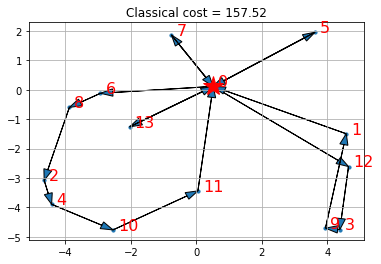

In [11]:
# Visualize the solution
def visualize_solution(xc, yc, x, C, n, K, title_str):
    plt.figure()
    plt.scatter(xc, yc, s=10)
    for i in range(len(xc)):
        plt.annotate(i, (xc[i] + 0.15, yc[i]), size=16, color='r')
    plt.plot(xc[0], yc[0], 'r*', ms=20)

    plt.grid()

    for ii in range(0, n ** 2):

        if x[ii] > 0:
            ix = ii // n
            iy = ii % n
            plt.arrow(xc[ix], yc[ix], xc[iy] - xc[ix], yc[iy] - yc[ix], length_includes_head=True, head_width=.25)

    plt.title(title_str+' cost = ' + str(int(C * 100) / 100.))
    plt.show()

if x is not None:
    visualize_solution(xc, yc, x, classical_cost, n, K, 'Classical')

In [12]:
from pygsp import *
from pygsp import graphs
from graph_coarsening.coarsening_utils import *
import graph_coarsening.graph_utils

G_pygsp = graphs.Graph(instance)
method = 'kron'  

# Parameters
r    = 0.5 # the extend of dimensionality reduction (r=0 means no reduction)
k    = 5  
kmax = int(3*k)
        
C, Gc, Call, Gall = coarsen(G_pygsp, K=k, r=r, method=method) 
metrics = coarsening_quality(G_pygsp, C, kmax=kmax)
n = Gc.N

print('{:16} | r: {:1.4}, nedges: {}, levels: {}, epsilon: {:1.4}'.format(method, metrics['r'], metrics['m'], len(Call), metrics['error_subspace'][k-1]))

2021-11-20 04:58:21,636:[WARNING](pygsp.graphs.graph._check_fourier_properties): The Fourier basis G.U is not available, we need to compute the Fourier basis. Explicitly call G.compute_fourier_basis() once beforehand to suppress the warning.


kron             | r: 0.5, nedges: 21, levels: 1, epsilon: 0.09482


In [13]:
coarsened_adjacency = Gall[1].W.toarray()
coarsened_adjacency.shape

(7, 7)

In [37]:
import pickle
G_pygsp = {'Gall': Gall, 'Call': Call}
with open(r'coarsened_graph', "wb") as output: 
  pickle.dump(G_pygsp, output)

In [14]:
# Renewed n and K for the coarsened adjacency matrix
n = 7
K = 3   # Half the number of vehicles

# Instantiate the classical optimizer class
classical_optimizer = ClassicalOptimizer(coarsened_adjacency,n,K)

# Print number of feasible solutions
print('Number of feasible solutions = ' + str(classical_optimizer.compute_allowed_combinations()))

Number of feasible solutions = 35.0


In [15]:
# Solve the problem in a classical fashion via CPLEX
x = None
z = None
try:
    x,classical_cost = classical_optimizer.cplex_solution()
    # Put the solution in the z variable
    z = [x[ii] for ii in range(n**2) if ii//n != ii%n]
    # Print the solution
    print(z)
except:
    print("CPLEX may be missing.")

[1.0, -0.0, -0.0, 0.0, 1.0, 1.0, 0.0, -0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0, 0.0, 1.0, -0.0, -0.0, -0.0, 0.0, 1.0, -0.0, -0.0, -0.0, 1.0, -0.0, 0.0, -0.0, -0.0, 0.0, 1.0, -0.0, -0.0, -0.0, -0.0, 0.0, 1.0, -0.0, -0.0, -0.0, -0.0, -0.0]


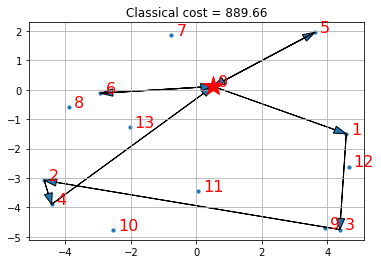

In [16]:
if x is not None:
    visualize_solution(xc, yc, x, classical_cost, n, K, 'Classical')

In [17]:
from qiskit.optimization import QuadraticProgram
from qiskit.optimization.algorithms import MinimumEigenOptimizer

class QuantumOptimizer:

    def __init__(self, instance, n, K):

        self.instance = instance
        self.n = n
        self.K = K

    def binary_representation(self,x_sol=0):

        instance = self.instance
        n = self.n
        K = self.K

        A = np.max(instance) * 100  # A parameter of cost function

        # Determine the weights w
        instance_vec = instance.reshape(n ** 2)
        w_list = [instance_vec[x] for x in range(n ** 2) if instance_vec[x] > 0]
        w = np.zeros(n * (n - 1))
        for ii in range(len(w_list)):
            w[ii] = w_list[ii]

        # Some variables I will use
        Id_n = np.eye(n)
        Im_n_1 = np.ones([n - 1, n - 1])
        Iv_n_1 = np.ones(n)
        Iv_n_1[0] = 0
        Iv_n = np.ones(n-1)
        neg_Iv_n_1 = np.ones(n) - Iv_n_1

        v = np.zeros([n, n*(n-1)])
        for ii in range(n):
            count = ii-1
            for jj in range(n*(n-1)):

                if jj//(n-1) == ii:
                    count = ii

                if jj//(n-1) != ii and jj%(n-1) == count:
                    v[ii][jj] = 1.

        vn = np.sum(v[1:], axis=0)

        # Q defines the interactions between variables
        Q = A*(np.kron(Id_n, Im_n_1) + np.dot(v.T, v))

        # g defines the contribution from the individual variables
        g = w - 2 * A * (np.kron(Iv_n_1,Iv_n) + vn.T) - \
                2 * A * K * (np.kron(neg_Iv_n_1, Iv_n) + v[0].T)

        # c is the constant offset
        c = 2 * A * (n-1) + 2 * A * (K ** 2)

        try:
            max(x_sol)
            # Evaluates the cost distance from a binary representation of a path
            fun = lambda x: np.dot(np.around(x), np.dot(Q, np.around(x))) + np.dot(g, np.around(x)) + c
            cost = fun(x_sol)
        except:
            cost = 0

        return Q, g, c, cost

    def construct_problem(self, Q, g, c) -> QuadraticProgram:
        qp = QuadraticProgram()
        for i in range(n * (n - 1)):
            qp.binary_var(str(i))
        qp.objective.quadratic = Q
        qp.objective.linear = g
        qp.objective.constant = c
        return qp

    def solve_problem(self, qp):
        aqua_globals.random_seed = 10598
        quantum_instance = QuantumInstance(BasicAer.get_backend('qasm_simulator'),
                                           seed_simulator=aqua_globals.random_seed,
                                           seed_transpiler=aqua_globals.random_seed)
#         from qiskit.algorithms import QAOA
# from qiskit_optimization.algorithms import MinimumEigenOptimizer
# backend = Aer.get_backend('statevector_simulator')
# qaoa = QAOA(optimizer = ADAM(), quantum_instance = backend, reps=1, initial_point = [0.1,0.1])
# eigen_optimizer = MinimumEigenOptimizer(min_eigen_solver = qaoa

        qaoa = QAOA(optimizer = ADAM(), quantum_instance = quantum_instance, initial_point = [0.1,0.1])
        optimizer = MinimumEigenOptimizer(min_eigen_solver=qaoa)
        result = optimizer.solve(qp)
        # compute cost of the obtained result
        _,_,_,level = self.binary_representation(x_sol=result.x)
        return result.x, level

/usr/local/lib/python3.7/dist-packages/qiskit/optimization/__init__.py:92: DeprecationWarning: The package qiskit.optimization is deprecated. It was moved/refactored to qiskit_optimization (pip install qiskit-optimization). For more information see <https://github.com/Qiskit/qiskit-aqua/blob/main/README.md#migration-guide>
  warn_package('optimization', 'qiskit_optimization', 'qiskit-optimization')


In [18]:
coarsened_adjacency.shape

(7, 7)

In [32]:
# Instantiate the quantum optimizer class with parameters:
quantum_optimizer = QuantumOptimizer(coarsened_adjacency, n, K)

In [33]:
# Check if the binary representation is correct
try:
    if z is not None:
        Q, g, c, binary_cost = quantum_optimizer.binary_representation(x_sol = z)
        print("Binary cost:", binary_cost, "classical cost:", classical_cost)
        if np.abs(binary_cost - classical_cost) < 0.01:
            print('Binary formulation is correct')
        else: print('Error in the binary formulation')
    else:
        print('Could not verify the correctness, due to CPLEX solution being unavailable.')
        Q, g, c, binary_cost = quantum_optimizer.binary_representation()
        print("Binary cost:", binary_cost)
except NameError as e:
    print("Warning: Please run the cells above first.")
    print(e)

Binary cost: 889.6647353350418 classical cost: 889.664735335116
Binary formulation is correct


In [ ]:
qp = quantum_optimizer.construct_problem(Q, g, c)
print(qp)

\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: CPLEX

Minimize
 obj: - 240141.731789869838 x1 - 240094.851302897034 x2 - 240155.519194278517 x3
      - 240160.282421500015 x4 - 240216.921823248675 x5 - 240194.134775928338 x6
      - 240141.731789869838 x7 - 119987.446123071626 x8 - 120017.730067805431 x9
      - 119991.433772175878 x10 - 119907.652861647861 x11
      - 119972.611599606011 x12 - 240094.851302897034 x13
      - 119987.446123071626 x14 - 120078.511457384433 x15
      - 120079.954520087354 x16 - 119845.634214657359 x17
      - 119992.504933698903 x18 - 240155.519194278517 x19
      - 120017.730067805431 x20 - 120078.511457384433 x21
      - 120027.435784204048 x22 - 119864.410263062906 x23
      - 119987.489068081632 x24 - 240160.282421500015 x25
      - 119991.433772175878 x26 - 120079.954520087354 x27
      - 120027.435784204048 x28 - 119999.406541152668 x29
      - 120065.526589059096 x30 - 240216.921823248675 x31
      - 119907.652861647

In [ ]:
quantum_solution, quantum_cost = quantum_optimizer.solve_problem(qp)

print(quantum_solution, quantum_cost)

In [ ]:
# Put the solution in a way that is compatible with the classical variables
x_quantum = np.zeros(n**2)
kk = 0
for ii in range(n ** 2):
    if ii // n != ii % n:
        x_quantum[ii] = quantum_solution[kk]
        kk +=  1


# visualize the solution
visualize_solution(xc, yc, x_quantum, quantum_cost, n, K, 'Quantum')

# and visualize the classical for comparison
if x is not None:
    visualize_solution(xc, yc, x, classical_cost, n, K, 'Classical')